# Use 50000R
 - For n_tets = 3, n_cells ~ 230,000
 - lowest overall rank for contact size
 - Get good meshes for n_tets = [1, 2, 3]
### Story so far
 - StMmLt study showed that taper_size needs to be ≤0.25 to prevent significant missing cells around the edge
 - And each preferred different p_h which was expected
    - use p_h = 8.5 as this has logic for being reasonable for everyone
 - optCombos showed best: 
 - ODT / lloyd - tweak per subject
 - perturb ≥ 20
 - exude = 0

In [1]:
from phd_helpers.paramOptimisation.getInfo import get_params3d, get_runtimes, combine_metric_dfs, score_value
from phd_helpers.paths import get_info_df, get_subject_stl_path, get_mesh, avg_edge_length
from phd_helpers.MeshQuality import check_mesh_quality, mesh_quality_summary, plot_bad_cells


from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv

In [2]:
# -------- PATHS --------------------------------------------- #
root_dir = Path('../../../../MeshPipeline/outputs/meshInd') # path to parent of output_root in set_parameters
study_prefix = 'study1' # start of dir name of output_root in set_parameters

out_dir = Path(f'outputs/meshInd-{study_prefix}') # path dir to save outputs in
suffixes = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l'] 

In [3]:
get_runtimes(root_dir, study_prefix, suffixes).to_csv(out_dir / 'runtimes.csv', index=False)
extra_params = [
    'cgal_params.sizing_field.taper_size',
    'cgal_params.sizing_field.n_tets',
    'cgal_params.optimisation.odt',
    'cgal_params.odt.max_iteration_number',
    'cgal_params.odt.freeze_bound',
    'cgal_params.optimisation.lloyd',
    'cgal_params.lloyd.max_iteration_number',
    'cgal_params.lloyd.freeze_bound'
    ]
get_params3d(root_dir, study_prefix, suffixes, extra_params).to_csv(out_dir / 'params.csv', index=False)

prefixes = [f'{study_prefix}{suffix}-0{suffix}' for suffix in suffixes] # only works if only need full_params.json
df_bone, df_cart, df_qual = combine_metric_dfs(out_dir, prefixes)

df_bone.to_csv(out_dir / 'df_bone.csv', index=False)
df_cart.to_csv(out_dir / 'df_cart.csv', index=False)
df_qual.to_csv(out_dir / 'df_qual.csv', index=False)

In [4]:
# LOAD DATA

df_bone = pd.read_csv(out_dir / 'df_bone.csv')
df_cart = pd.read_csv(out_dir / 'df_cart.csv')
df_qual = pd.read_csv(out_dir / 'df_qual.csv')

df_param = pd.read_csv(out_dir / 'params.csv')
df_run = pd.read_csv(out_dir / 'runtimes.csv')

In [5]:
bone = 'tpm'

d_metric2 = 'max'
d_metric1 = '99'
iteration_cart = 'remesh2d'
iteration_bone = 'remesh2d'
loc = 'i'

qual_metric = '99%'
qual_part = 'full'

metrics = [

    # fidelity (keep high)
    f'bone_{iteration_bone}_d{loc}_{d_metric1}',
    f'bone_{iteration_bone}_d{loc}_{d_metric2}',
    f'cart_{iteration_cart}_d{loc}_{d_metric1}',
    f'cart_{iteration_cart}_d{loc}_{d_metric2}',

    # quality (keep high)
    f'{qual_part}_min_angle_{qual_metric}',
    f'{qual_part}_scaled_jacobian_{qual_metric}',
    f'{qual_part}_aspect_ratio_{qual_metric}',
    f'{qual_part}_radius_ratio_{qual_metric}',
    f'{qual_part}_min_angle_worst',
    f'{qual_part}_scaled_jacobian_worst',
    f'{qual_part}_aspect_ratio_worst',
    f'{qual_part}_radius_ratio_worst',

]


bone_df = df_bone[
    ['sub', 'bone', 'run_id', f'{iteration_bone}_d{loc}_{d_metric1}', f'{iteration_bone}_d{loc}_{d_metric2}', 'remesh3d_vol']
].rename(columns={
    f'{iteration_bone}_d{loc}_{d_metric1}': f'bone_{iteration_bone}_d{loc}_{d_metric1}',
    f'{iteration_bone}_d{loc}_{d_metric2}': f'bone_{iteration_bone}_d{loc}_{d_metric2}'
})

cart_df = df_cart[
    ['sub', 'bone', 'run_id', f'{iteration_cart}_d{loc}_{d_metric1}', f'{iteration_cart}_d{loc}_{d_metric2}']
].rename(columns={
    f'{iteration_cart}_d{loc}_{d_metric1}': f'cart_{iteration_cart}_d{loc}_{d_metric1}',
    f'{iteration_cart}_d{loc}_{d_metric2}': f'cart_{iteration_cart}_d{loc}_{d_metric2}'
})

qual = df_qual[
    [
        'sub', 'bone', 'run_id',
        f'{qual_part}_min_angle_{qual_metric}',
        f'{qual_part}_scaled_jacobian_{qual_metric}',
        f'{qual_part}_aspect_ratio_{qual_metric}',
        f'{qual_part}_radius_ratio_{qual_metric}',
        f'{qual_part}_min_angle_worst',
        f'{qual_part}_scaled_jacobian_worst',
        f'{qual_part}_aspect_ratio_worst',
        f'{qual_part}_radius_ratio_worst',
        'full_n_cells',
    ]
]

df = (
    bone_df
    .merge(cart_df, on=['sub', 'bone', 'run_id'], how='inner')
    .merge(qual, on=['sub', 'bone', 'run_id'], how='inner')
)
df = df[(df['bone_remesh2d_di_max']<0.1) & (df['cart_remesh2d_di_max']<0.1)] # remove any where odt chipped tets

#df = df[df['bone']==bone]

print(len(df))

314


Highest element count:
	50000R - 419177


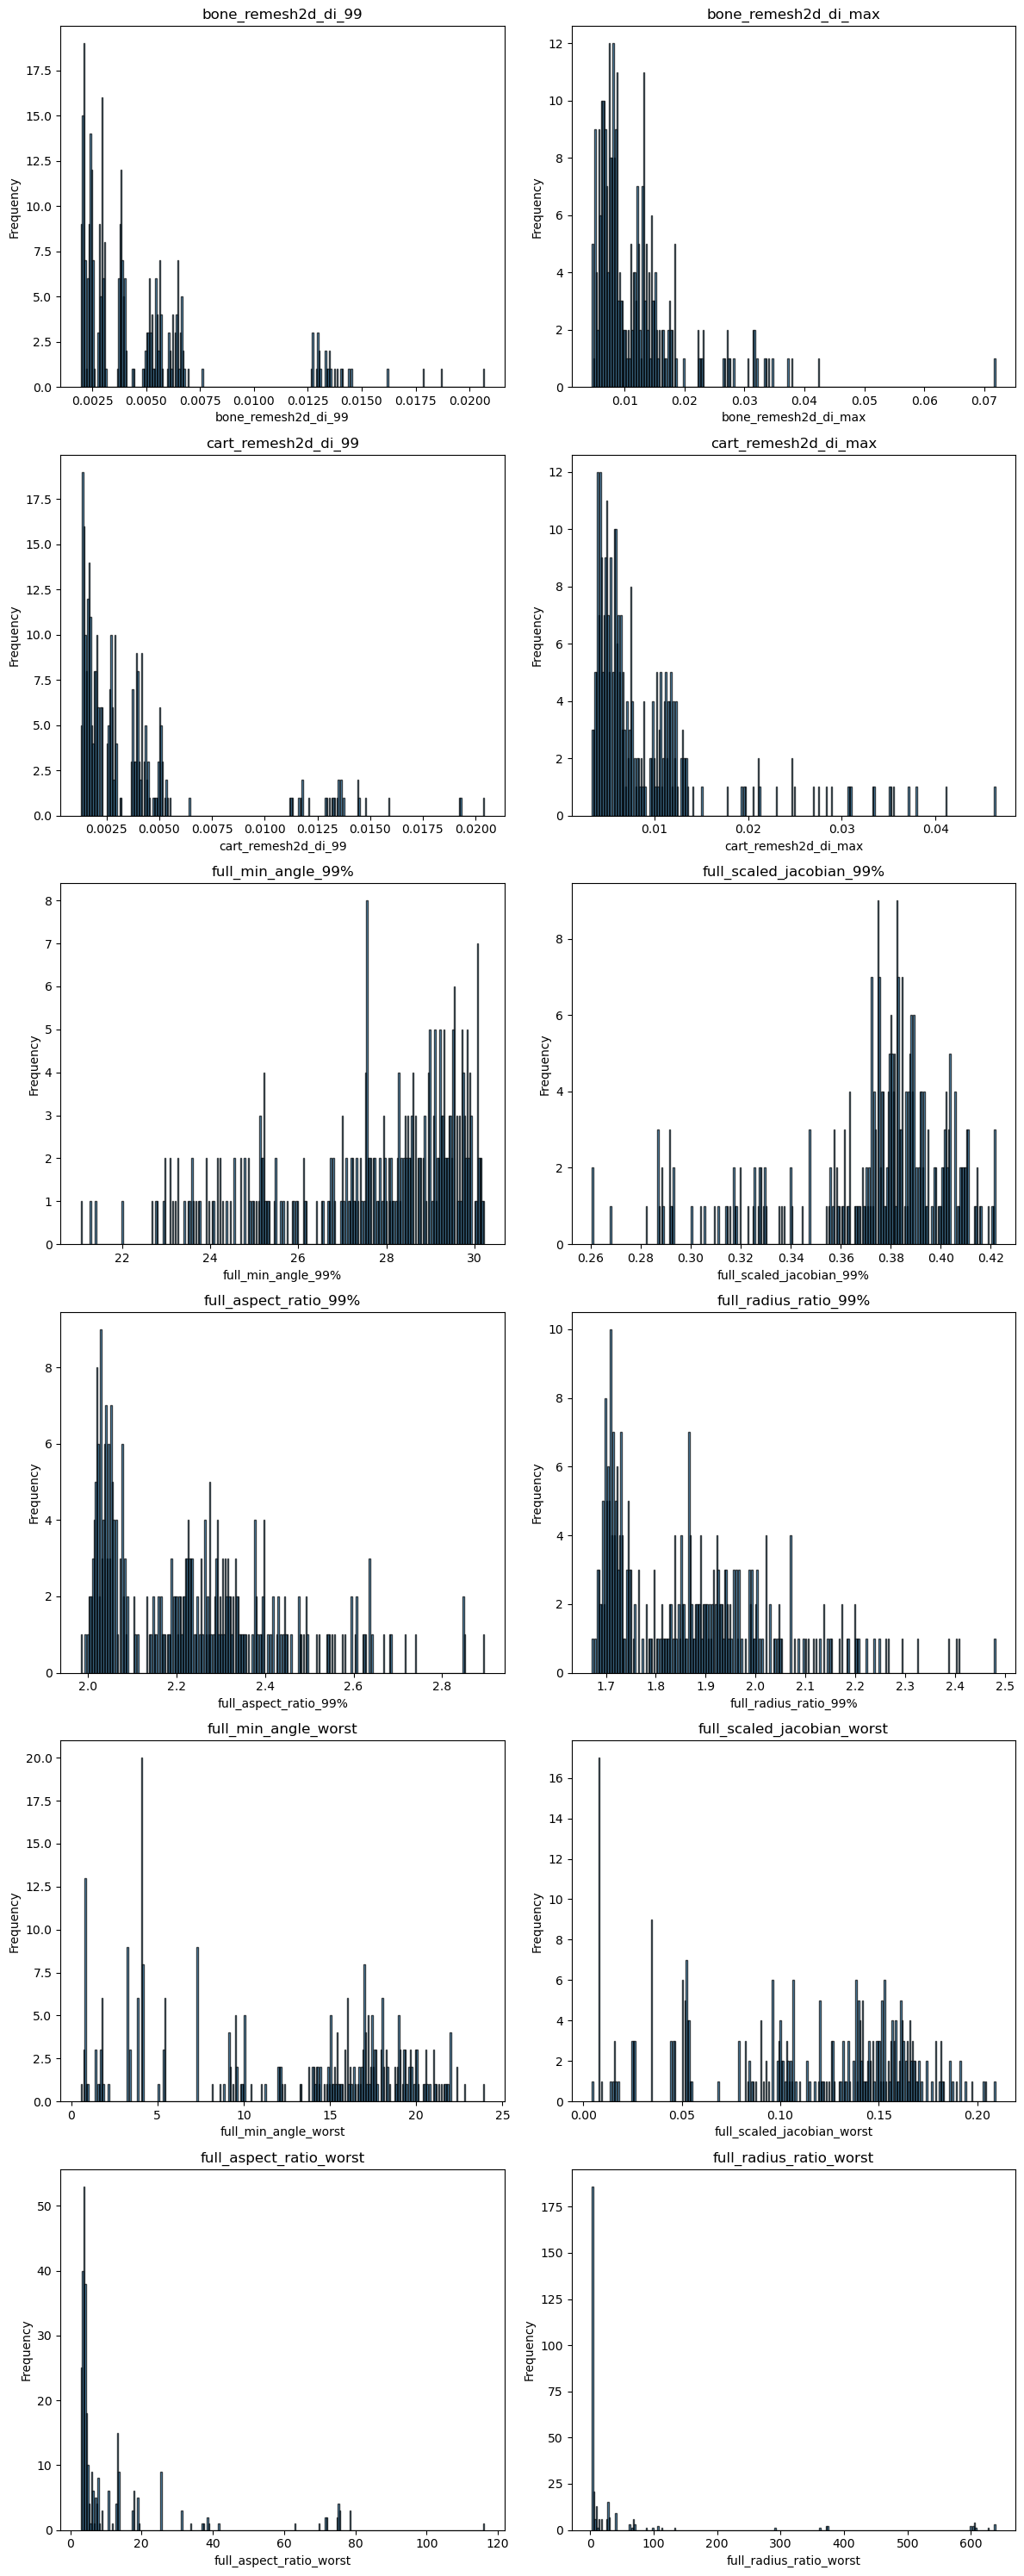

In [6]:
fig, ax = plt.subplots(6, 2, figsize=(12, 30))
ax = ax.flatten()

most_cells = qual.sort_values('full_n_cells').iloc[-1]
print(f'Highest element count:\n\t{most_cells['sub']} - {most_cells['full_n_cells']}')
for sub in df['sub'].unique():
    subject, side = sub[:-1], sub[-1]
    stl_path = get_subject_stl_path(subject, side)
    orig_bone = get_mesh(stl_path, 'tpm')
    L = avg_edge_length(orig_bone)
    #print(f"\n{sub}\n - Average edge length: {L:.4f} mm")
    #print(f' -   Max element count: {qual[qual['sub']==sub]['total_tets'].max()}')

    sub_df = df[df['sub']==sub]
    bins = int(len(df) / 1)
    for i, metric in enumerate(metrics):
        values = sub_df[metric]#[df_param['fd_bone']==0.8]
        # Histogram
        ax[i].hist(values, bins=bins, edgecolor='black', alpha=0.7, label=sub)
        ax[i].set_title(metric)
        ax[i].set_xlabel(metric)
        ax[i].set_ylabel('Frequency')

        #ax[i].legend()

plt.tight_layout()
plt.show()

In [7]:
q_weight = 1 

chosen_metrics = {

    f'{qual_part}_min_angle_99%': {
        'ideal': 30,
        'acceptable': 15,
        'weight': q_weight
    },

    f'{qual_part}_scaled_jacobian_99%': {
        'ideal': 0.4,
        'acceptable': 0.3,
        'weight': q_weight
    },

    f'{qual_part}_aspect_ratio_99%': {
        'ideal': 3,
        'acceptable': 4,
        'weight': q_weight
    },

    f'{qual_part}_radius_ratio_99%': {
        'ideal': 3,
        'acceptable': 4,
        'weight': q_weight
    },

    f'{qual_part}_min_angle_worst': {
        'ideal': 15,
        'acceptable': 10,
        'weight': q_weight
    },

    f'{qual_part}_scaled_jacobian_worst': {
        'ideal': 0.3,
        'acceptable': 0.2,
        'weight': q_weight
    },

    f'{qual_part}_aspect_ratio_worst': {
        'ideal': 4,
        'acceptable': 5,
        'weight': q_weight
    },

    f'{qual_part}_radius_ratio_worst': {
        'ideal': 4,
        'acceptable': 5,
        'weight': q_weight
    },
}

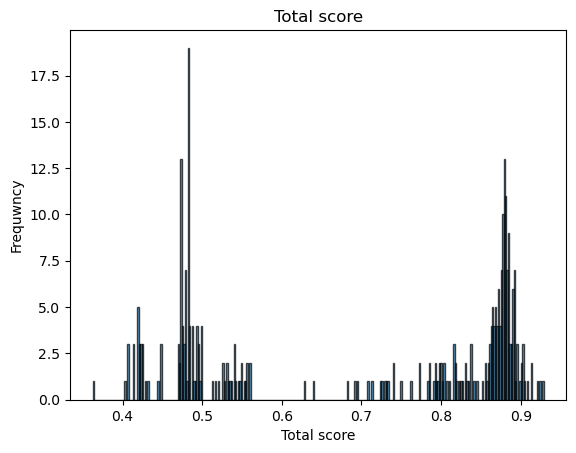

In [8]:
# Get scores

decay = 3
linear_floor = 0.5
total_weight = sum([w['weight'] for w in chosen_metrics.values()])

df_score = df[['sub', 'bone', 'run_id']].copy()
total = 0
for metric, bounds in chosen_metrics.items():
    score = score_value(df[metric], bounds['ideal'], bounds['acceptable'], linear_floor, decay)
    df_score[metric] = score
    total += score * bounds['weight'] / total_weight
df_score['total'] = total
df_score['rank_within_case'] = (
    df_score.groupby(['sub', 'bone'])['total']
    .rank(ascending=False, method='average')
)

# Merge with params

df_score = df_score.sort_values('total', ascending=False)

df_score_param = df_score.merge(
    df_param,
    on=['sub', 'bone', 'run_id'],
    how='left'
)
df_score_qual = df_score.merge(
    df_qual,
    on=['sub', 'bone', 'run_id'],
    how='left'
)

# Plot overall scores
fig, ax = plt.subplots()

subs = df_score['sub'].unique()
for sub in subs:
    sub_df = df_score[df_score['sub'] == sub]

    ax.hist(sub_df['total'], bins=round(len(df_score)/1), edgecolor='black', alpha=0.7, label=sub)

    ax.set_title("Total score")
    ax.set_xlabel('Total score')
    ax.set_ylabel('Frequwncy')
    #ax.legend()

In [9]:
# Best accross all subjects

df_grouped_rank = (
    df_score_param
    .groupby(df_param.columns[3:].to_list(), dropna=False)
    .agg(
        mean_rank=('rank_within_case', 'mean'),
        median_rank=('rank_within_case', 'median'),
        best_rank=('rank_within_case', 'min'),
        n_runs=('rank_within_case', 'size')
    )
    .reset_index()
    .sort_values('mean_rank')
)
df_grouped_rank.head(10)

,cgal_params.sizing_field.taper_size,cgal_params.sizing_field.n_tets,cgal_params.optimisation.odt,cgal_params.odt.max_iteration_number,cgal_params.odt.freeze_bound,cgal_params.optimisation.lloyd,cgal_params.lloyd.max_iteration_number,cgal_params.lloyd.freeze_bound,mean_rank,median_rank,best_rank,n_runs
122,0.25,3.0,True,10,0.0100,False,0,0.001,1.0,1.0,1.0,1
118,0.25,3.0,True,10,0.0005,False,0,0.001,5.0,5.0,5.0,1
185,0.25,4.0,True,20,0.0100,False,10,0.010,7.5,7.5,3.0,2
130,0.25,3.0,True,20,0.0100,False,0,0.001,8.0,8.0,8.0,1
189,0.25,4.0,True,30,0.0100,False,10,0.010,9.0,9.0,4.0,2
138,0.25,3.0,True,30,0.0100,False,0,0.001,11.0,11.0,11.0,1
126,0.25,3.0,True,20,0.0005,False,0,0.001,13.0,13.0,13.0,1
116,0.25,3.0,True,10,0.0001,False,0,0.001,14.0,14.0,14.0,1
158,0.25,3.5,True,20,0.0005,False,10,0.010,15.0,15.0,4.0,2
124,0.25,3.0,True,20,0.0001,False,0,0.001,16.0,16.0,16.0,1


In [10]:
best_per_tet = df_score_param.groupby(['cgal_params.sizing_field.n_tets', 'bone']).first()
best_per_tet

sub     run_id  full_min_angle_99%  \
cgal_params.sizing_field.n_tets bone                                          
1.0                             mc1   50000R   0-0-0-0g            0.849522   
                                tpm   50000R   0-0-6-0e            0.858031   
1.5                             mc1   50000R   0-0-0-0i            0.798330   
                                tpm   50000R  0-0-11-0i            0.822697   
2.0                             mc1   50000R  0-0-13-0g            0.931382   
                                tpm   50000R  0-0-10-0d            0.953863   
2.5                             mc1   50000R  0-0-15-0i            0.910924   
                                tpm   50000R  0-0-24-0i            0.938061   
3.0                             mc1   50000R  0-0-28-0g            0.918392   
                                tpm   50000R  0-0-12-0b            0.989430   
3.5                             mc1   50000R   0-0-6-0l            0.995489   
                                tpm   50000R   0-0-6-0k            0.942205   
4.0                             mc1   50000R  0-0-18-0l            1.000000   
                                tpm   50000R  0-0-16-0l            0.999957   

                                      full_scaled_jacobian_99%  \
cgal_params.sizing_field.n_tets bone                             
1.0                             mc1                   0.804966   
                                tpm                   0.838402   
1.5                             mc1                   0.637095   
                                tpm                   0.647085   
2.0                             mc1                   0.958249   
                                tpm                   1.000000   
2.5                             mc1                   0.966640   
                                tpm                   1.000000   
3.0                             mc1                   0.966217   
                                tpm                   0.917121   
3.5                             mc1                   0.902216   
                                tpm                   1.000000   
4.0                             mc1                   0.941084   
                                tpm                   0.945103   

                                      full_aspect_ratio_99%  \
cgal_params.sizing_field.n_tets bone                          
1.0                             mc1                     1.0   
                                tpm                     1.0   
1.5                             mc1                     1.0   
                                tpm                     1.0   
2.0                             mc1                     1.0   
                                tpm                     1.0   
2.5                             mc1                     1.0   
                                tpm                     1.0   
3.0                             mc1                     1.0   
                                tpm                     1.0   
3.5                             mc1                     1.0   
                                tpm                     1.0   
4.0                             mc1                     1.0   
                                tpm                     1.0   

                                      full_radius_ratio_99%  \
cgal_params.sizing_field.n_tets bone                          
1.0                             mc1                     1.0   
                                tpm                     1.0   
1.5                             mc1                     1.0   
                                tpm                     1.0   
2.0                             mc1                     1.0   
                                tpm                     1.0   
2.5                             mc1                     1.0   
                                tpm                     1.0   
3.0                             mc1                     1.0   
                 

In [11]:
best_per_tet.merge(df_score_qual[(df_score_qual['sub']==sub)])[['sub', 'bone', 'run_id']+[x for x in df_score_qual.columns if '_y' in x]]

,sub,bone,run_id,full_min_angle_worst_y,full_min_angle_99%_y,full_radius_ratio_worst_y,full_radius_ratio_99%_y,full_aspect_ratio_worst_y,full_aspect_ratio_99%_y,full_scaled_jacobian_worst_y,full_scaled_jacobian_99%_y
0,50000R,mc1,0-0-0-0g,17.184336,25.485656,3.467791,2.001806,3.791733,2.394267,0.169384,0.360993
1,50000R,tpm,0-0-6-0e,18.303712,25.740923,3.854639,1.955659,4.065794,2.334249,0.144185,0.367680
2,50000R,mc1,0-0-0-0i,17.432722,23.949890,3.617704,2.095661,3.805566,2.493591,0.162615,0.327419
3,50000R,tpm,0-0-11-0i,18.287306,24.680921,3.528027,1.989631,3.921088,2.378377,0.126901,0.329417
4,50000R,mc1,0-0-13-0g,18.245651,27.941450,3.006940,1.877078,3.493984,2.245765,0.161730,0.391650
5,50000R,tpm,0-0-10-0d,17.444867,28.615890,3.793613,1.801416,3.865188,2.159890,0.150544,0.403644
6,50000R,mc1,0-0-15-0i,19.422152,27.327706,3.049857,1.924286,3.358592,2.299622,0.204203,0.393328
7,50000R,tpm,0-0-24-0i,18.008670,28.141833,3.707358,1.857080,3.739941,2.228621,0.138417,0.409050
8,50000R,mc1,0-0-28-0g,17.521798,27.551771,3.127338,1.929453,3.574287,2.303645,0.209352,0.393243
9,50000R,tpm,0-0-12-0b,21.946640,29.682914,3.055249,1.713387,3.114523,2.033452,0.183184,0.383424


## Final meshes

In [ ]:
path1 = '/Users/maro/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/WorkPackages/WorkPackages/TMCJ-Contact/Computational/MeshPipeline/outputs/meshInd/study1e/meshes/50000R/tpm-mc1/3Dmesh/mesh-0-0-6.vtu'
path2 = '/Users/maro/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/WorkPackages/WorkPackages/TMCJ-Contact/Computational/MeshPipeline/outputs/meshInd/study1d/meshes/50000R/tpm-mc1/3Dmesh/mesh-0-0-10.vtu'
path3 = '/Users/maro/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/WorkPackages/WorkPackages/TMCJ-Contact/Computational/MeshPipeline/outputs/meshInd/study1b/meshes/50000R/tpm-mc1/3Dmesh/mesh-0-0-12.vtu'
T1 = pv.read(path1)
T2 = pv.read(path2)
T3 = pv.read(path3)
print(T1.n_cells, T2.n_cells, T3.n_cells)
T1.plot()
T2.plot()
T3.plot()

46595 114683 246929


Widget(value='<iframe src="http://localhost:51577/index.html?ui=P_0x350738a10_28&reconnect=auto" class="pyvist…

Widget(value='<iframe src="http://localhost:51577/index.html?ui=P_0x32e523ef0_29&reconnect=auto" class="pyvist…

Widget(value='<iframe src="http://localhost:51577/index.html?ui=P_0x350739700_30&reconnect=auto" class="pyvist…

In [ ]:
path1 = '/Users/maro/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/WorkPackages/WorkPackages/TMCJ-Contact/Computational/MeshPipeline/outputs/meshInd/study1g/meshes/50000R/mc1-tpm/3Dmesh/mesh-0-0-0.vtu'
path2 = '/Users/maro/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/WorkPackages/WorkPackages/TMCJ-Contact/Computational/MeshPipeline/outputs/meshInd/study1g/meshes/50000R/mc1-tpm/3Dmesh/mesh-0-0-13.vtu'
path3 = '/Users/maro/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/WorkPackages/WorkPackages/TMCJ-Contact/Computational/MeshPipeline/outputs/meshInd/study1g/meshes/50000R/mc1-tpm/3Dmesh/mesh-0-0-28.vtu'
T1 = pv.read(path1)
T2 = pv.read(path2)
T3 = pv.read(path3)
print(T1.n_cells, T2.n_cells, T3.n_cells)
T1.plot()
T2.plot()
T3.plot()

# Can't use ODT if n_tets = 1
 - Results in it putting holes all over the surface
 - odt=false and taper_size=0.5, resulted in holes at the edge
 Need taper_size ≤ 0.25 to prevent edge holes

In [41]:
import subprocess

path_MeshPipeline_main = '../../../../MeshPipeline/main.py'
subprocess.run(["python", path_MeshPipeline_main])


Updating parameters.json
	Wrote /Users/maro/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/WorkPackages/WorkPackages/TMCJ-Contact/Computational/MeshPipeline/set_parameters/parameters.json


Full parameter file saved to outputs/holes/params/full_params-8.json

SUBJECT: 50000R
	BONES: tpm-mc1
		STEP: 2Dmesh
			RUN ID: -0
			Runtime: 1.518s - ok
		STEP: cartilage
			RUN ID: -0-0
			Runtime: 1.524s - ok
		STEP: 3Dmesh
			RUN ID: -0-0-0
			Runtime: 13.058s - ok


CompletedProcess(args=['python', '../../../../MeshPipeline/main.py'], returncode=0)

In [ ]:
path = '/Users/maro/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/WorkPackages/WorkPackages/TMCJ-Contact/Computational/notebooks/MeshPipeline/ParamOptimisation/meshIndependance/outputs/holes/meshes/50000R/tpm-mc1/3Dmesh/mesh-0-0-0.vtu'
pv.read(path).plot()